# <center> Prediccion de Precios en Bienes Raices &mdash; Regresion Avanzada con PyCaret </center>

# Tabla de Contenido

1. [Introduccion](#Introduccion)
2. [Configuracion e Instalacion](#Configuracion-e-Instalacion)
3. [Entendimiento de los Datos](#Entendimiento-de-los-Datos)
4. [Manipulacion y Limpieza de Datos](#Manipulacion-y-Limpieza-de-Datos)
    1. [Dropping Data](#Dropping-Data)
    2. [Tratamiento de Valores Faltantes](#Tratamiento-de-Valores-Faltantes)
    3. [Derived Data](#Derived-Data)
5. [Analisis de Datos (EDA)](#Analisis-de-Datos)
    1. [Analisis Univariable](#Analisis-Univariable)
    2. [Analisis Bivariable](#Analisis-Bivariable)
6. [Preparacion de Datos y Modelado](#Preparacion-de-Datos-y-Modelado)
    1. [Codificacion de Variables](#Codificacion-de-Variables)
    2. [Train / Test Split y Escalado](#Train-Test-Split)
    3. [Seleccion de Caracteristicas (RFE + VIF)](#Seleccion-de-Caracteristicas)
7. [Construccion del Modelo](#Construccion-del-Modelo)
    1. [AutoML con PyCaret](#AutoML-con-PyCaret)
    2. [Regresion Lineal (baseline)](#Regresion-Lineal)
    3. [Ridge Regression](#Ridge-Regression)
    4. [Lasso Regression](#Lasso-Regression)
    5. [ElasticNet Regression](#ElasticNet-Regression)
    6. [Comparacion de Modelos](#Comparacion-de-Modelos)
8. [Analisis de Residuos](#Analisis-de-Residuos)
9. [Prediccion](#Prediccion)
10. [Conclusiones y Observaciones](#Conclusiones-y-Observaciones)

# Introduccion

### Integrantes del Grupo:
- Daniel Tarqui
- David Rivas
- Harold Sanchez
- Jonas Maidana

## Entendimiento del Negocio

Una empresa de vivienda llamada **Surprise Housing** ha decidido ingresar a un nuevo
mercado inmobiliario. La empresa usa analisis de datos para **comprar casas por debajo de
su valor real y revenderlas a un precio mayor**. Para ello recopilo un conjunto de datos
de ventas de viviendas (archivo `_data/dataset.csv`).

La compania quiere responder:

* **Que variables son significativas** para predecir el precio de una casa.
* **Que tan bien** describen esas variables el precio de una casa.
* **Cual es el valor optimo de lambda** ($\lambda$) para las regresiones Ridge y Lasso.

### Objetivo del Negocio

Modelar el precio de las casas en funcion de las variables independientes disponibles,
usando **regresion con regularizacion**. La gerencia usara el modelo para entender como
varian los precios con cada variable y enfocar su estrategia de inversion en las
caracteristicas que generan mayores retornos.

# Configuracion e Instalacion

Importamos las librerias de manipulacion de datos, visualizacion, machine learning
(`scikit-learn`), estadistica (`statsmodels`) y AutoML (`PyCaret`).

In [1]:
# Importar librerias requeridas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias de Machine Learning (scikit-learn)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Librerias de Estadistica
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Ignorar alertas para una salida mas limpia
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizacion
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.options.display.float_format = '{:.3f}'.format
pd.set_option('display.max_columns', 100)

# Semilla global para reproducibilidad
SEED = 42

In [2]:
# Leer el dataset CSV en un DataFrame
DATA_FILE_PATH = '_data/dataset.csv'
raw_data = pd.read_csv(DATA_FILE_PATH)
print('Dataset cargado:', raw_data.shape[0], 'filas x', raw_data.shape[1], 'columnas')

Dataset cargado: 1460 filas x 81 columnas


# Entendimiento de los Datos

Antes de limpiar o modelar exploramos la estructura del dataset: dimensiones, tipos de
variables, estadisticos descriptivos y la variable objetivo `SalePrice`.

In [3]:
# Vistazo inicial a las primeras filas
raw_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Dimensiones e informacion general de tipos y no-nulos
print('Dimensiones:', raw_data.shape)
raw_data.info()

Dimensiones: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null

In [5]:
# Estadisticos descriptivos de las variables numericas
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.000,730.500,421.610,1.000,365.750,730.500,1095.250,1460.000
MSSubClass,1460.000,56.897,42.301,20.000,20.000,50.000,70.000,190.000
LotFrontage,1201.000,70.050,24.285,21.000,59.000,69.000,80.000,313.000
LotArea,1460.000,10516.828,9981.265,1300.000,7553.500,9478.500,11601.500,215245.000
OverallQual,1460.000,6.099,1.383,1.000,5.000,6.000,7.000,10.000
OverallCond,1460.000,5.575,1.113,1.000,5.000,5.000,6.000,9.000
YearBuilt,1460.000,1971.268,30.203,1872.000,1954.000,1973.000,2000.000,2010.000
YearRemodAdd,1460.000,1984.866,20.645,1950.000,1967.000,1994.000,2004.000,2010.000
MasVnrArea,1452.000,103.685,181.066,0.000,0.000,0.000,166.000,1600.000
BsmtFinSF1,1460.000,443.640,456.098,0.000,0.000,383.500,712.250,5644.000


In [6]:
# Separar nombres de columnas numericas y categoricas
numeric_cols = raw_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = raw_data.select_dtypes(include=['object']).columns.tolist()

print('Variables NUMERICAS  ({}): {}'.format(len(numeric_cols), numeric_cols))
print()
print('Variables CATEGORICAS ({}): {}'.format(len(categorical_cols), categorical_cols))

Variables NUMERICAS  (38): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables CATEGORICAS (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functio

In [7]:
# Distribucion de la variable objetivo SalePrice
print(raw_data['SalePrice'].describe())
print('\nAsimetria (skew) de SalePrice:', round(raw_data['SalePrice'].skew(), 3))
print('Asimetria (skew) de log(SalePrice):', round(np.log1p(raw_data['SalePrice']).skew(), 3))

count     1460.000
mean    180921.196
std      79442.503
min      34900.000
25%     129975.000
50%     163000.000
75%     214000.000
max     755000.000
Name: SalePrice, dtype: float64

Asimetria (skew) de SalePrice: 1.883
Asimetria (skew) de log(SalePrice): 0.121


**Observaciones del entendimiento de datos:**

* El dataset tiene **1460 registros y 81 columnas** (incluye `Id` y el objetivo `SalePrice`).
* Hay **38 variables numericas** y **43 categoricas**.
* `SalePrice` esta **fuertemente sesgada a la derecha** (skew ~1.88). Al aplicar la
  transformacion `log(1 + x)` la asimetria baja a ~0.12, quedando casi normal. Por eso
  **modelaremos el logaritmo del precio**, lo que estabiliza la varianza y mejora el ajuste
  de los modelos lineales.
* Muchos `NA` del CSV **no son datos faltantes reales** sino una categoria valida
  ("sin sotano", "sin garaje", "sin piscina", etc.), segun `_data/data_description.txt`.
  Esto se trata cuidadosamente en la limpieza.

# Manipulacion y Limpieza de Datos

Trabajamos sobre una copia para preservar el dataset original.

In [8]:
# Copia de trabajo
df = raw_data.copy()

## Dropping Data

Eliminamos columnas que no aportan informacion al modelo:

* **`Id`**: es solo un identificador unico, no es predictivo.
* **`Utilities`**: el 99.9% de los registros tiene el mismo valor (`AllPub`) -> casi constante.
* **`Street`**: el 99.6% es `Pave` -> casi constante.

Tambien verificamos filas **duplicadas**.

In [9]:
# Verificar duplicados (no deberia haber, pero es un control de calidad estandar)
print('Filas duplicadas exactas:', df.duplicated().sum())
print('Filas duplicadas (ignorando Id):', df.drop(columns=['Id']).duplicated().sum())

# Eliminar columnas no informativas / casi constantes
cols_to_drop = ['Id', 'Utilities', 'Street']
df = df.drop(columns=cols_to_drop)
print('\nColumnas eliminadas:', cols_to_drop)
print('Nuevo shape:', df.shape)

Filas duplicadas exactas: 0
Filas duplicadas (ignorando Id): 0

Columnas eliminadas: ['Id', 'Utilities', 'Street']
Nuevo shape: (1460, 78)


## Tratamiento de Valores Faltantes

Distinguimos dos tipos de "faltantes":

1. **`NA` que significa AUSENCIA de la caracteristica** (no es un dato perdido). Segun el
   diccionario de datos, en estas columnas `NA` = "No tiene". Se imputan con la categoria
   explicita `'None'` (o `0` si son numericas asociadas).
2. **Faltantes reales** (errores u omisiones de captura), que se imputan con una estrategia
   estadistica adecuada:
   * `LotFrontage`: mediana **por vecindario** (`Neighborhood`), ya que los frentes de lote
     son similares dentro de un mismo barrio.
   * `MasVnrArea`: `0` (sin revestimiento de mamposteria).
   * `Electrical`: la **moda** (un unico registro faltante).

In [10]:
# Conteo de faltantes ANTES de imputar
missing_before = df.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print('Columnas con valores faltantes ({}):'.format(len(missing_before)))
print(missing_before)

Columnas con valores faltantes (19):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


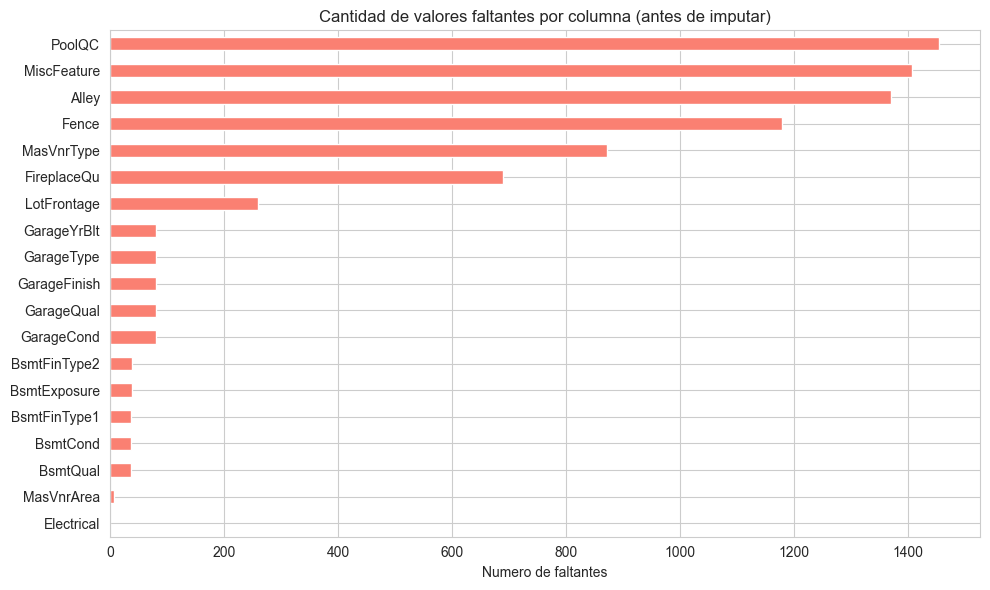

In [11]:
# Visualizacion de los faltantes
plt.figure(figsize=(10, 6))
missing_before.sort_values().plot(kind='barh', color='salmon')
plt.title('Cantidad de valores faltantes por columna (antes de imputar)')
plt.xlabel('Numero de faltantes')
plt.tight_layout()
plt.show()

In [12]:
# 1) NA = "No tiene la caracteristica" -> categoria explicita 'None'
none_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
             'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']
df[none_cols] = df[none_cols].fillna('None')

# 2) Numericas asociadas a "no tiene" -> 0
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)   # 0 = sin garaje
df['MasVnrArea']  = df['MasVnrArea'].fillna(0)    # 0 = sin revestimiento

# 3) LotFrontage -> mediana por vecindario (fallback a la mediana global)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# 4) Electrical (1 faltante) -> moda
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Verificacion: no deben quedar faltantes
print('Total de valores faltantes despues de imputar:', int(df.isna().sum().sum()))

Total de valores faltantes despues de imputar:

 0


## Derived Data

Creamos **nuevas metricas derivadas** que capturan mejor el valor de una propiedad que las
columnas crudas por separado:

* `HouseAge` = anios de la casa al momento de la venta.
* `RemodAge` = anios desde la ultima remodelacion.
* `TotalSF` = superficie total (sotano + 1er piso + 2do piso).
* `TotalBath` = total de banios ponderados (los medios banios cuentan 0.5).
* `TotalPorchSF` = superficie total de porches/terrazas.
* Indicadores binarios: `HasPool`, `Has2ndFloor`, `HasGarage`, `HasBsmt`, `HasFireplace`,
  `IsRemodeled`.

In [13]:
# Metricas continuas derivadas
df['HouseAge']     = (df['YrSold'] - df['YearBuilt']).clip(lower=0)
df['RemodAge']     = (df['YrSold'] - df['YearRemodAdd']).clip(lower=0)
df['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath']    = (df['FullBath'] + 0.5 * df['HalfBath'] +
                      df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] +
                      df['ScreenPorch'] + df['WoodDeckSF'])

# Indicadores binarios (presencia / ausencia)
df['HasPool']      = (df['PoolArea'] > 0).astype(int)
df['Has2ndFloor']  = (df['2ndFlrSF'] > 0).astype(int)
df['HasGarage']    = (df['GarageArea'] > 0).astype(int)
df['HasBsmt']      = (df['TotalBsmtSF'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['IsRemodeled']  = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# MSSubClass es un CODIGO (no una magnitud) -> tratarla como categorica
df['MSSubClass'] = df['MSSubClass'].astype(str)

print('Nuevas columnas derivadas creadas. Shape actual:', df.shape)
df[['HouseAge', 'RemodAge', 'TotalSF', 'TotalBath', 'TotalPorchSF']].describe().T

Nuevas columnas derivadas creadas. Shape actual:

 (1460, 89)


,count,mean,std,min,25%,50%,75%,max
HouseAge,1460.000,36.548,30.250,0.000,8.000,35.000,54.000,136.000
RemodAge,1460.000,22.951,20.640,0.000,4.000,14.000,41.000,60.000
TotalSF,1460.000,2567.049,821.714,334.000,2009.500,2474.000,3004.000,11752.000
TotalBath,1460.000,2.211,0.785,1.000,2.000,2.000,2.500,6.000
TotalPorchSF,1460.000,181.329,156.656,0.000,45.000,164.000,266.000,1027.000


# Analisis de Datos (EDA)

## Analisis Univariable

Estudiamos la distribucion de la variable objetivo y de las principales variables numericas
y categoricas.

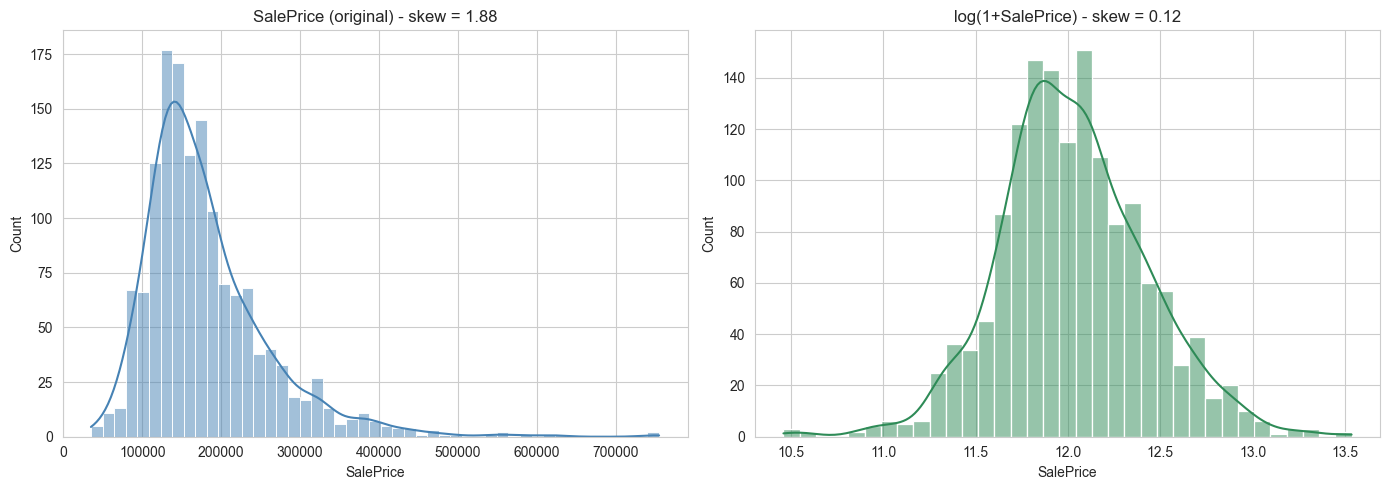

In [14]:
# Distribucion de SalePrice: escala original vs escala logaritmica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice (original) - skew = {:.2f}'.format(df['SalePrice'].skew()))
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('log(1+SalePrice) - skew = {:.2f}'.format(np.log1p(df['SalePrice']).skew()))
plt.tight_layout()
plt.show()

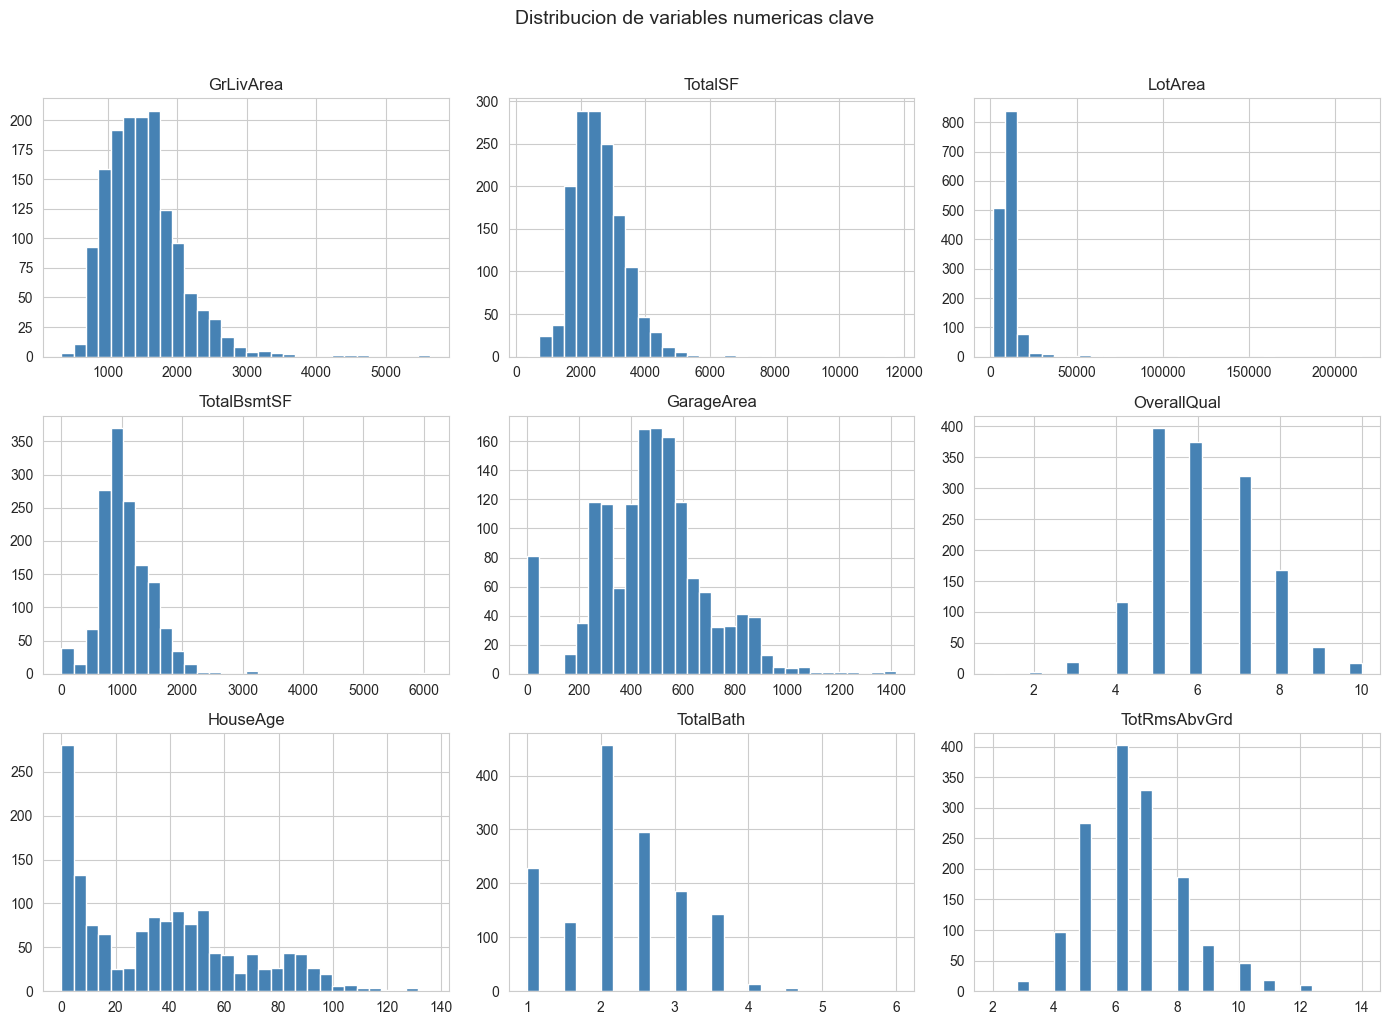

In [15]:
# Histogramas de las principales variables numericas continuas
key_numeric = ['GrLivArea', 'TotalSF', 'LotArea', 'TotalBsmtSF', 'GarageArea',
               'OverallQual', 'HouseAge', 'TotalBath', 'TotRmsAbvGrd']
df[key_numeric].hist(bins=30, figsize=(14, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribucion de variables numericas clave', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Variables Categoricas

Frecuencia de las categorias mas relevantes.

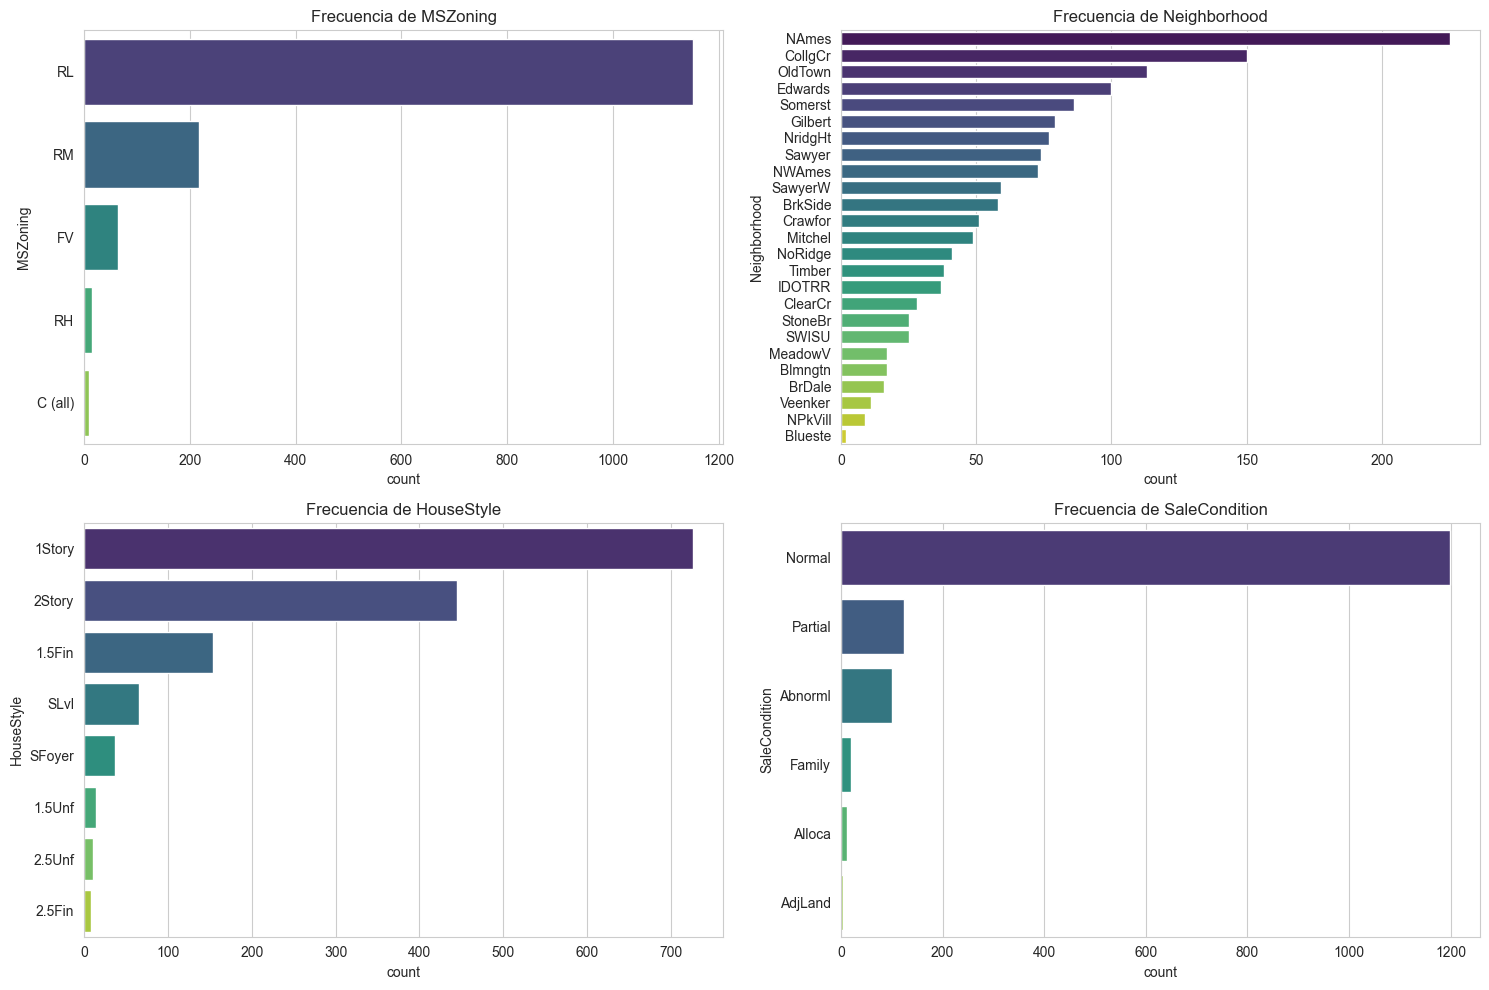

In [16]:
# Conteo de categorias para variables categoricas representativas
key_cat = ['MSZoning', 'Neighborhood', 'HouseStyle', 'SaleCondition']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.ravel(), key_cat):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette='viridis')
    ax.set_title('Frecuencia de ' + col)
plt.tight_layout()
plt.show()

## Analisis Bivariable

Relacion de las variables con el precio (`SalePrice`). Usamos correlaciones para las
numericas y boxplots para las categoricas.

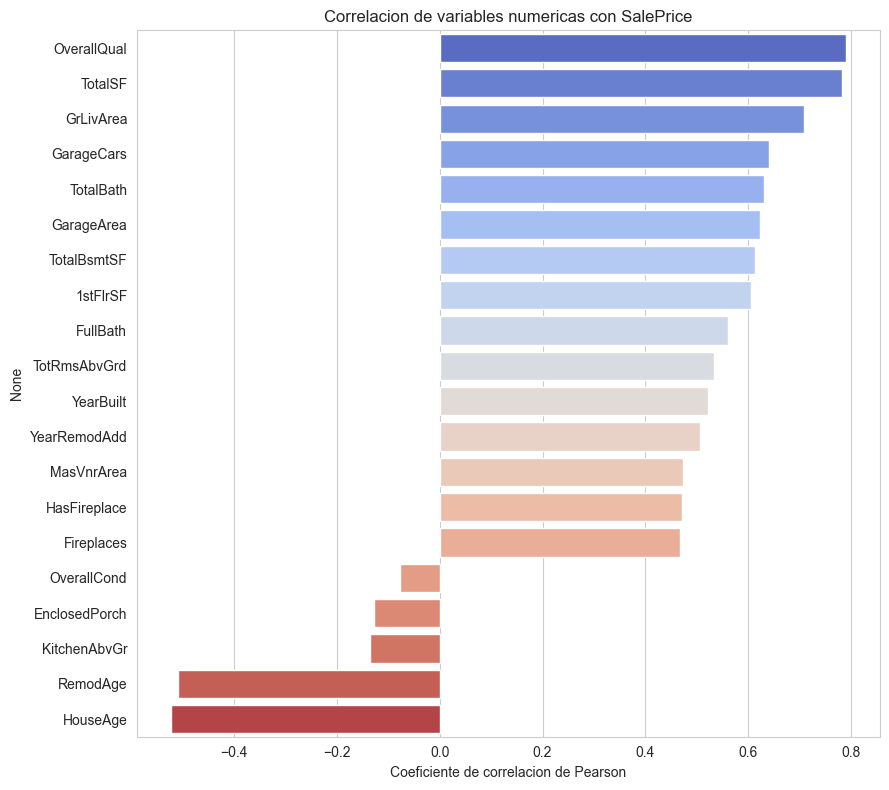

Variables mas correlacionadas con el precio:
OverallQual    0.791
TotalSF        0.782
GrLivArea      0.709
GarageCars     0.640
TotalBath      0.632
GarageArea     0.623
TotalBsmtSF    0.614
1stFlrSF       0.606
FullBath       0.561
TotRmsAbvGrd   0.534
Name: SalePrice, dtype: float64


In [17]:
# Correlacion de las variables numericas con SalePrice (top 15)
numeric_df = df.select_dtypes(include=[np.number])
corr_with_price = numeric_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

plt.figure(figsize=(9, 8))
top_corr = pd.concat([corr_with_price.head(15), corr_with_price.tail(5)])
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title('Correlacion de variables numericas con SalePrice')
plt.xlabel('Coeficiente de correlacion de Pearson')
plt.tight_layout()
plt.show()

print('Variables mas correlacionadas con el precio:')
print(corr_with_price.head(10))

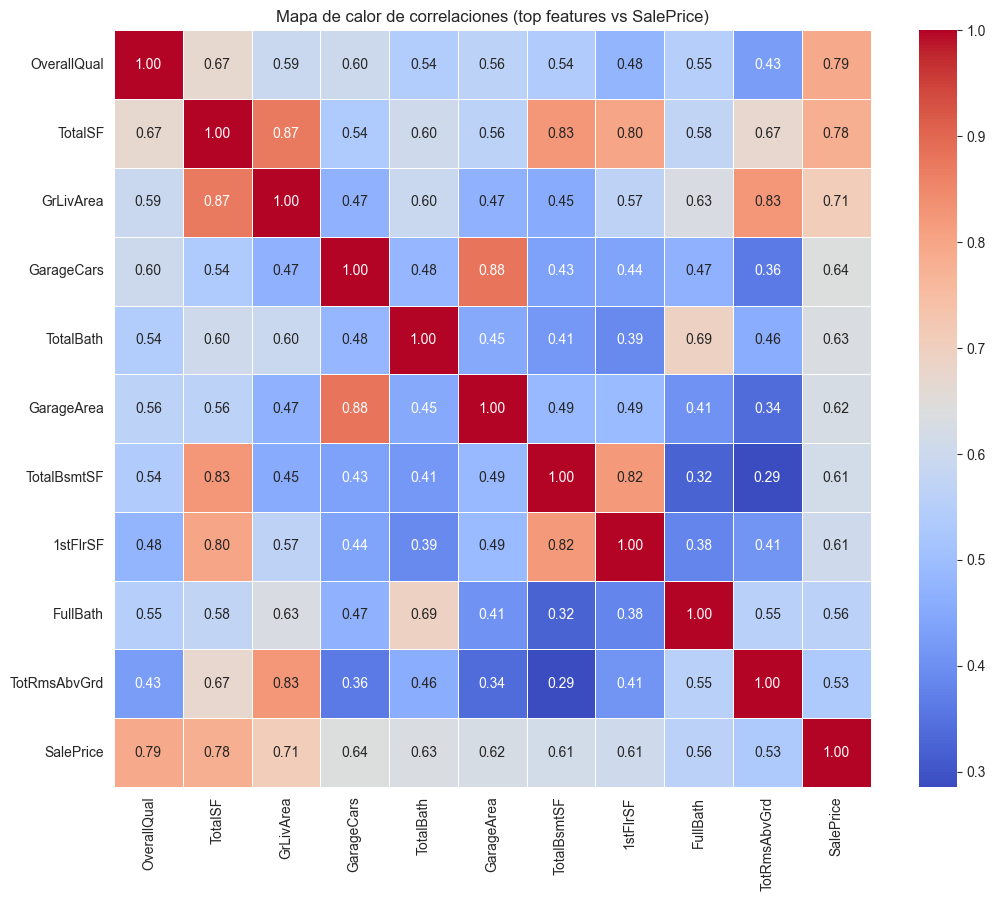

In [18]:
# Mapa de calor de correlaciones entre las variables mas relacionadas con el precio
top_features = corr_with_price.head(10).index.tolist() + ['SalePrice']
plt.figure(figsize=(11, 9))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Mapa de calor de correlaciones (top features vs SalePrice)')
plt.tight_layout()
plt.show()

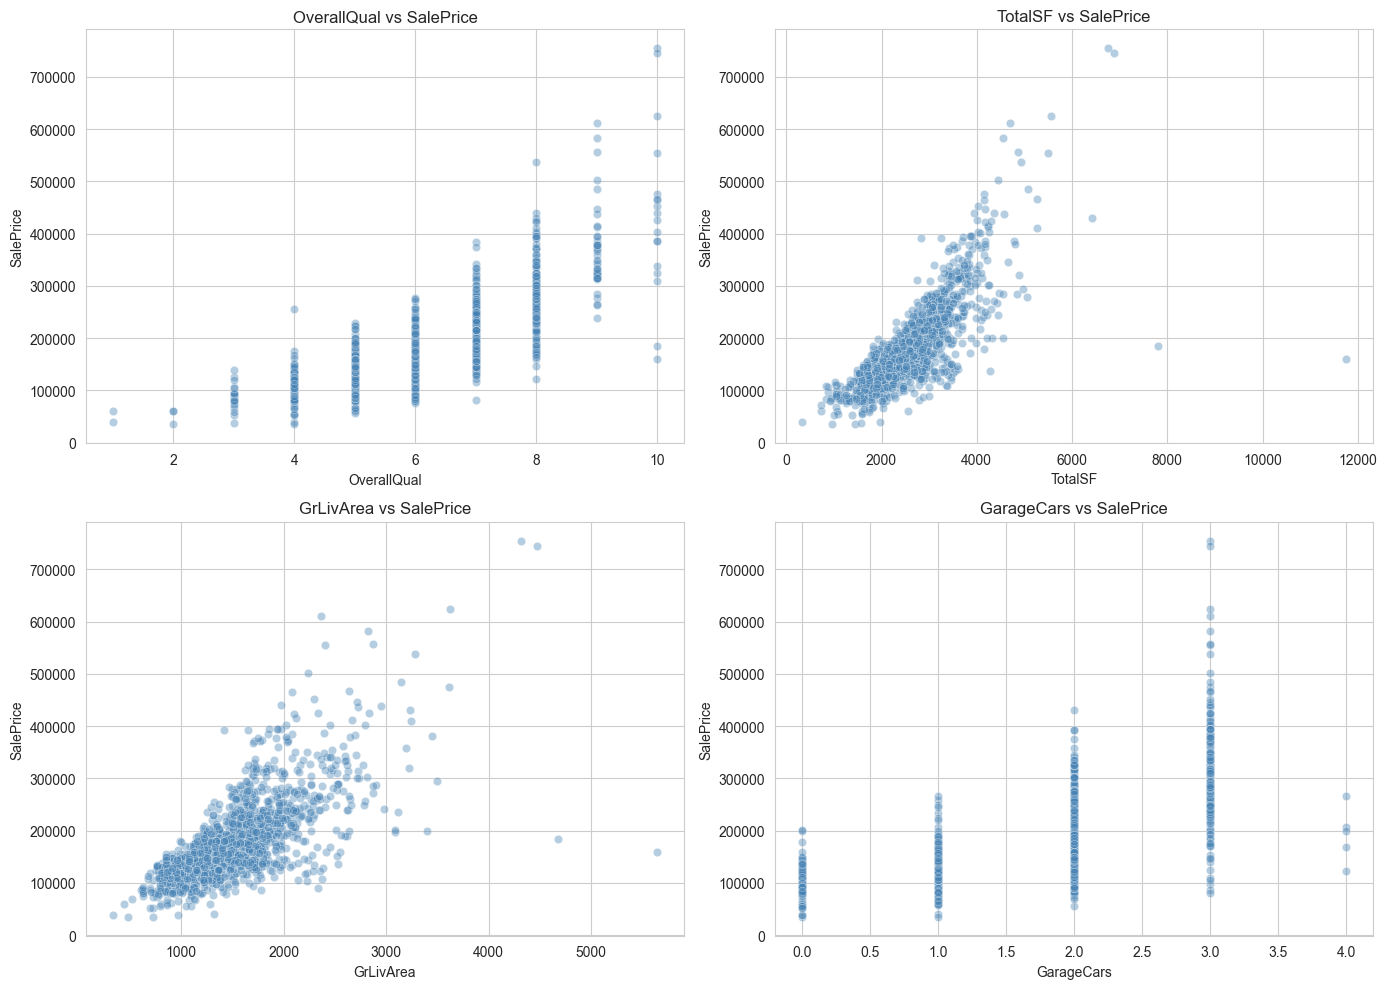

In [19]:
# Relacion de las variables numericas mas fuertes con el precio (dispersión)
strong = ['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), strong):
    sns.scatterplot(data=df, x=col, y='SalePrice', alpha=0.4, ax=ax, color='steelblue')
    ax.set_title('{} vs SalePrice'.format(col))
plt.tight_layout()
plt.show()

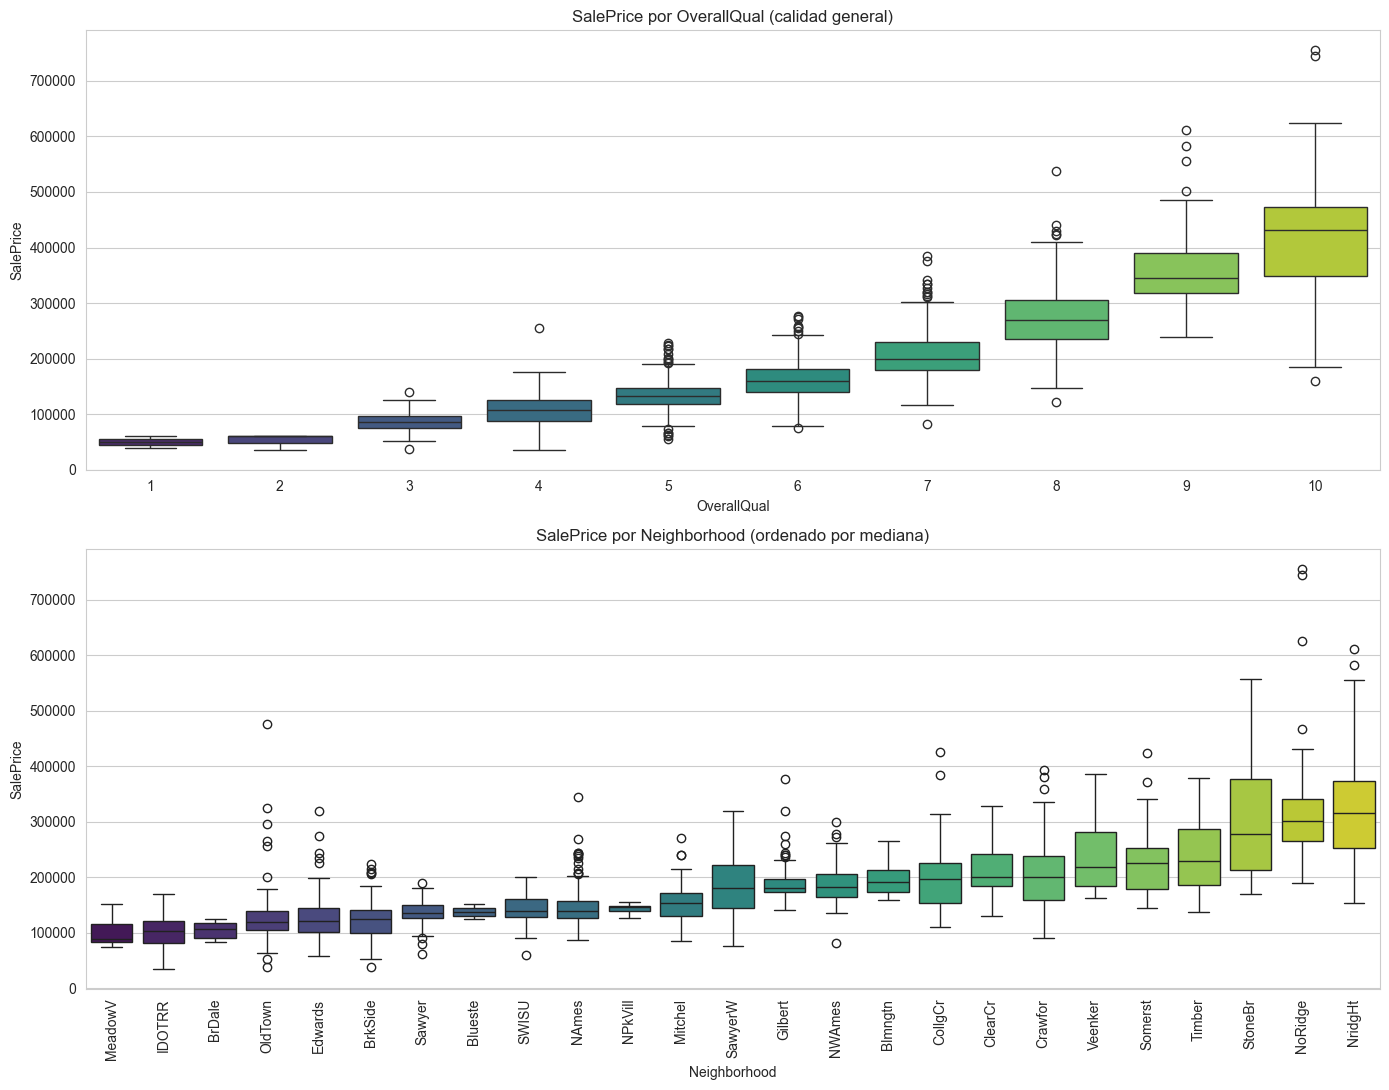

In [20]:
# Precio segun calidad general y vecindario (categoricas/ordinales fuertes)
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[0], palette='viridis')
axes[0].set_title('SalePrice por OverallQual (calidad general)')
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, ax=axes[1], palette='viridis')
axes[1].set_title('SalePrice por Neighborhood (ordenado por mediana)')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Observaciones del EDA:**

* `OverallQual` (calidad general) y las medidas de **superficie** (`TotalSF`, `GrLivArea`,
  `TotalBsmtSF`) son las variables **mas correlacionadas** con el precio.
* El **vecindario** influye fuertemente: hay barrios con medianas de precio muy superiores.
* La capacidad del garaje (`GarageCars`, `GarageArea`) y la cantidad de banios tambien
  muestran relacion positiva clara con el precio.

# Preparacion de Datos y Modelado

## Codificacion de Variables

* **Variables ordinales** (calidades tipo Ex > Gd > TA > Fa > Po): se mapean a numeros que
  respetan el orden, ya que llevan informacion ordinal real.
* **Variables nominales** (sin orden): se convierten en **variables dummy** con
  `pd.get_dummies(drop_first=True)` para evitar la trampa de la multicolinealidad.
* La variable objetivo se transforma a **escala logaritmica** `log(1 + SalePrice)`.

In [21]:
# --- Mapas ordinales (respetan el orden natural de las categorias) ---
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in qual_cols:
    df[col] = df[col].map(qual_map).astype(int)

df['BsmtExposure'] = df['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}).astype(int)
fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df['BsmtFinType1'] = df['BsmtFinType1'].map(fin_map).astype(int)
df['BsmtFinType2'] = df['BsmtFinType2'].map(fin_map).astype(int)
df['GarageFinish'] = df['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}).astype(int)
df['Functional']   = df['Functional'].map({'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
                                            'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}).astype(int)
df['CentralAir']   = df['CentralAir'].map({'N': 0, 'Y': 1}).astype(int)
df['PavedDrive']   = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2}).astype(int)
df['LandSlope']    = df['LandSlope'].map({'Sev': 0, 'Mod': 1, 'Gtl': 2}).astype(int)

print('Columnas object restantes (nominales para dummies):',
      df.select_dtypes(include='object').shape[1])

Columnas object restantes (nominales para dummies): 24


In [22]:
# Guardamos una version limpia (con categoricas como texto) para PyCaret AutoML
clean_df = df.copy()

# --- Variables dummy para las nominales restantes ---
df_encoded = pd.get_dummies(df, drop_first=True)
# Asegurar tipo numerico (algunos dummies salen como bool)
df_encoded = df_encoded.astype({c: 'int' for c in df_encoded.select_dtypes('bool').columns})

print('Shape tras codificacion (incluye SalePrice):', df_encoded.shape)

Shape tras codificacion (incluye SalePrice): (1460, 230)


In [23]:
# Separar features (X) y objetivo (y). El objetivo va en escala logaritmica.
y = np.log1p(df_encoded['SalePrice'])
X = df_encoded.drop(columns=['SalePrice'])
print('X:', X.shape, '| y:', y.shape)

X: (1460, 229) | y: (1460,)


## Train / Test Split

Dividimos en **80% entrenamiento / 20% prueba** con semilla fija para reproducibilidad.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1168, 229) | Test: (292, 229)


### Escalado de Caracteristicas - StandardScaler

Los modelos con regularizacion (Ridge/Lasso/ElasticNet) **penalizan la magnitud de los
coeficientes**, por lo que requieren que las variables esten en la misma escala. Ajustamos
el `StandardScaler` **solo con los datos de entrenamiento** (para no filtrar informacion del
test) y transformamos ambos conjuntos.

In [25]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),
                              columns=X_test.columns, index=X_test.index)
print('Escalado aplicado. Media ~0 y desviacion ~1 en train.')
X_train_scaled.iloc[:3, :5]

Escalado aplicado. Media ~0 y desviacion ~1 en train.


,LotFrontage,LotArea,LandSlope,OverallQual,OverallCond
254,-0.021,-0.213,0.222,-0.820,0.372
1066,-0.502,-0.265,0.222,-0.089,1.269
638,-0.152,-0.178,0.222,-0.820,1.269


## Seleccion de Caracteristicas (RFE + VIF)

Aplicamos dos tecnicas complementarias vistas en clase:

* **RFE (Recursive Feature Elimination):** elimina recursivamente las variables menos
  importantes hasta quedarse con un subconjunto. Lo usamos para obtener un conjunto
  parsimonioso e interpretable.
* **VIF (Variance Inflation Factor):** detecta multicolinealidad. Eliminamos iterativamente
  las variables con VIF alto (> 10) del subconjunto seleccionado.

Este subconjunto reducido alimenta un modelo lineal **interpretable** (OLS). Para las
regresiones regularizadas usamos el conjunto completo de variables, ya que la propia
regularizacion realiza la seleccion (Lasso) o el encogimiento (Ridge).

In [26]:
# RFE: seleccionar las 30 variables mas relevantes con una regresion lineal como estimador
N_FEATURES = 30
rfe = RFE(estimator=LinearRegression(), n_features_to_select=N_FEATURES, step=10)
rfe.fit(X_train_scaled, y_train)
rfe_features = X_train_scaled.columns[rfe.support_].tolist()
print('{} variables seleccionadas por RFE:'.format(len(rfe_features)))
print(rfe_features)

30 variables seleccionadas por RFE:
['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'WoodDeckSF', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HasGarage', 'MSSubClass_190', 'MSSubClass_20', 'MSSubClass_30', 'MSSubClass_40', 'MSSubClass_45', 'MSSubClass_50', 'MSSubClass_60', 'MSSubClass_70', 'MSSubClass_75', 'MSSubClass_80', 'MSSubClass_85', 'MSSubClass_90', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'Exterior1st_CBlock', 'Exterior2nd_CBlock', 'GarageType_None']


In [27]:
# VIF: eliminar iterativamente variables con multicolinealidad alta (VIF > 10)
def calcular_vif(data):
    vif = pd.DataFrame()
    vif['feature'] = data.columns
    vif['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif.sort_values('VIF', ascending=False)

selected = list(rfe_features)
while True:
    vif_df = calcular_vif(X_train_scaled[selected])
    peor = vif_df.iloc[0]
    if peor['VIF'] > 10 and len(selected) > 5:
        selected.remove(peor['feature'])
    else:
        break

print('Variables finales tras RFE + VIF ({}):'.format(len(selected)))
print(selected)
print('\nVIF final (todas < 10):')
calcular_vif(X_train_scaled[selected])

Variables finales tras RFE + VIF (21):
['2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath', 'FullBath', 'WoodDeckSF', 'TotalSF', 'TotalPorchSF', 'HasGarage', 'MSSubClass_190', 'MSSubClass_30', 'MSSubClass_40', 'MSSubClass_50', 'MSSubClass_60', 'MSSubClass_70', 'MSSubClass_75', 'MSSubClass_80', 'MSSubClass_85', 'MSSubClass_90', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'Exterior1st_CBlock']

VIF final (todas < 10):


,feature,VIF
0,2ndFlrSF,5.075
12,MSSubClass_60,4.604
6,TotalPorchSF,2.637
4,WoodDeckSF,2.383
5,TotalSF,2.017
3,FullBath,1.920
11,MSSubClass_50,1.891
13,MSSubClass_70,1.827
14,MSSubClass_75,1.508
18,BldgType_Twnhs,1.284


# Construccion del Modelo

Probamos una **cantidad razonable de modelos** y elegimos el mejor segun las metricas clave
(R2 y RMSE). Trabajamos sobre el logaritmo del precio, por lo que el RMSE esta en unidades
logaritmicas.

## AutoML con PyCaret

PyCaret automatiza el preprocesamiento, la **validacion cruzada (10-fold)** y la comparacion
de multiples algoritmos. Lo usamos como **seleccion automatica de modelos**: comparamos
modelos lineales, regularizados y de **ensemble** (Random Forest, Gradient Boosting, LightGBM).

In [28]:
from pycaret.regression import (setup, compare_models, pull, create_model,
                                 tune_model, predict_model, finalize_model)

# Dataset para PyCaret: version limpia con el objetivo en escala log
pycaret_df = clean_df.copy()
pycaret_df['SalePrice'] = np.log1p(pycaret_df['SalePrice'])

reg_setup = setup(data=pycaret_df, target='SalePrice', session_id=SEED,
                  normalize=True, train_size=0.80, verbose=False)
print('PyCaret configurado correctamente.')

PyCaret configurado correctamente.


In [29]:
# Comparar modelos lineales, regularizados y de ensemble mediante validacion cruzada
best_models = compare_models(
    include=['lr', 'ridge', 'lasso', 'en', 'rf', 'gbr', 'lightgbm'],
    sort='R2', n_select=1)
pycaret_results = pull()
pycaret_results

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.0859,0.0165,0.1261,0.8921,0.0097,0.0072,0.0940
lightgbm,Light Gradient Boosting Machine,0.0868,0.0167,0.1270,0.8907,0.0098,0.0072,0.1450
rf,Random Forest Regressor,0.0947,0.0204,0.1398,0.8678,0.0108,0.0079,0.1550
ridge,Ridge Regression,0.0907,0.0256,0.1516,0.8273,0.0116,0.0076,0.2180
lasso,Lasso Regression,0.3036,0.1526,0.3888,-0.0074,0.0298,0.0252,0.1850
en,Elastic Net,0.3036,0.1526,0.3888,-0.0074,0.0298,0.0252,0.0320
lr,Linear Regression,58503706447.1886,447392602720762666680320.0000,435232207260.3011,-3427058656060640086458368.0000,3.3933,4830792109.6910,0.2740


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.086,0.017,0.126,0.892,0.010,0.007,0.094
lightgbm,Light Gradient Boosting Machine,0.087,0.017,0.127,0.891,0.010,0.007,0.145
rf,Random Forest Regressor,0.095,0.020,0.140,0.868,0.011,0.008,0.155
ridge,Ridge Regression,0.091,0.026,0.152,0.827,0.012,0.008,0.218
lasso,Lasso Regression,0.304,0.153,0.389,-0.007,0.030,0.025,0.185
en,Elastic Net,0.304,0.153,0.389,-0.007,0.030,0.025,0.032
lr,Linear Regression,58503706447.189,447392602720762666680320.000,435232207260.301,-3427058656060640086458368.000,3.393,4830792109.691,0.274


**Lectura del leaderboard de PyCaret:**

PyCaret entrena cada modelo con sus **hiperparametros por defecto**. Por eso `Lasso` y
`ElasticNet` aparecen aqui con un R2 muy bajo: su `alpha` por defecto (= 1.0) es demasiado
alto para el objetivo en escala logaritmica y **sobre-regulariza** (encoge casi todos los
coeficientes hacia cero). Esto **motiva el ajuste del lambda** que hacemos a continuacion con
`GridSearchCV`: al optimizar lambda, Lasso pasa de R2 ~ 0 a R2 ~ 0.89.

Los modelos de **ensemble** (Gradient Boosting, LightGBM) logran el mejor R2 sin ajuste manual,
lo que confirma su potencia. Sin embargo, el objetivo de negocio exige **interpretar el efecto
de cada variable y reportar el lambda optimo**, por lo que nos centramos en los modelos
**lineales regularizados**: como veremos, el Lasso ajustado iguala el desempeno del mejor
ensemble manteniendo la interpretabilidad.

## Regresion Lineal (baseline)

Ajustamos una **regresion lineal OLS** con `statsmodels` sobre el subconjunto reducido
(RFE + VIF). Sirve como linea base interpretable y para inspeccionar la significancia
estadistica (p-values) de las variables.

In [30]:
# OLS sobre las variables seleccionadas (RFE + VIF)
# has_constant='add' fuerza la columna constante en ambos conjuntos (evita el desajuste
# de dimensiones si alguna dummy queda constante en el subconjunto de test).
X_train_ols = sm.add_constant(X_train_scaled[selected], has_constant='add')
X_test_ols  = sm.add_constant(X_test_scaled[selected], has_constant='add')
ols_model = sm.OLS(y_train, X_train_ols).fit()

# Metricas del baseline
ols_pred_train = ols_model.predict(X_train_ols)
ols_pred_test  = ols_model.predict(X_test_ols)
ols_r2_train = r2_score(y_train, ols_pred_train)
ols_r2_test  = r2_score(y_test, ols_pred_test)
ols_rmse_test = np.sqrt(mean_squared_error(y_test, ols_pred_test))
print('OLS  ->  R2 train: {:.4f} | R2 test: {:.4f} | RMSE test: {:.4f}'.format(
    ols_r2_train, ols_r2_test, ols_rmse_test))
print(ols_model.summary().tables[0])

OLS  ->  R2 train: 0.7272 | R2 test: 0.7720 | RMSE test: 0.2063
                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     145.4
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          4.41e-305
Time:                        20:53:20   Log-Likelihood:                 199.72
No. Observations:                1168   AIC:                            -355.4
Df Residuals:                    1146   BIC:                            -244.0
Df Model:                          21                                         
Covariance Type:            nonrobust                                         


## Ridge Regression

Ridge aplica penalizacion **L2** (encoge los coeficientes hacia cero sin anularlos).
Buscamos el **valor optimo de lambda (`alpha`)** con `GridSearchCV` y validacion cruzada de
5 folds.

In [31]:
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

ridge_alphas = np.logspace(-2, 4, 60)
ridge_grid = GridSearchCV(Ridge(), {'alpha': ridge_alphas},
                          scoring='r2', cv=kfold, n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

ridge_best = ridge_grid.best_estimator_
ridge_lambda = ridge_grid.best_params_['alpha']
ridge_r2_train = ridge_best.score(X_train_scaled, y_train)
ridge_r2_test  = ridge_best.score(X_test_scaled, y_test)
ridge_rmse_test = np.sqrt(mean_squared_error(y_test, ridge_best.predict(X_test_scaled)))

print('Ridge  ->  lambda optimo: {:.4f}'.format(ridge_lambda))
print('R2 train: {:.4f} | R2 test: {:.4f} | RMSE test: {:.4f}'.format(
    ridge_r2_train, ridge_r2_test, ridge_rmse_test))

Ridge  ->  lambda optimo: 476.3938
R2 train: 0.9128 | R2 test: 0.8856 | RMSE test: 0.1461


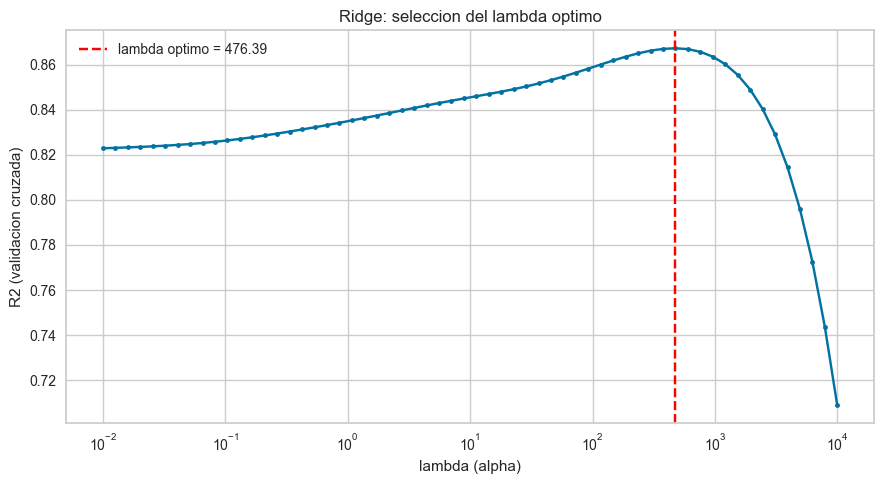

In [32]:
# Curva de validacion: R2 (CV) en funcion de lambda
plt.figure(figsize=(9, 5))
plt.semilogx(ridge_alphas, ridge_grid.cv_results_['mean_test_score'], marker='.')
plt.axvline(ridge_lambda, color='red', linestyle='--',
            label='lambda optimo = {:.2f}'.format(ridge_lambda))
plt.xlabel('lambda (alpha)'); plt.ylabel('R2 (validacion cruzada)')
plt.title('Ridge: seleccion del lambda optimo'); plt.legend()
plt.tight_layout(); plt.show()

## Lasso Regression

Lasso aplica penalizacion **L1**, que **anula** los coeficientes de las variables menos
relevantes (seleccion automatica de variables). Buscamos su lambda optimo con `GridSearchCV`.

In [33]:
lasso_alphas = np.logspace(-4, 0, 60)
lasso_grid = GridSearchCV(Lasso(max_iter=20000), {'alpha': lasso_alphas},
                          scoring='r2', cv=kfold, n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)

lasso_best = lasso_grid.best_estimator_
lasso_lambda = lasso_grid.best_params_['alpha']
lasso_r2_train = lasso_best.score(X_train_scaled, y_train)
lasso_r2_test  = lasso_best.score(X_test_scaled, y_test)
lasso_rmse_test = np.sqrt(mean_squared_error(y_test, lasso_best.predict(X_test_scaled)))
n_zero = int(np.sum(lasso_best.coef_ == 0))

print('Lasso  ->  lambda optimo: {:.5f}'.format(lasso_lambda))
print('R2 train: {:.4f} | R2 test: {:.4f} | RMSE test: {:.4f}'.format(
    lasso_r2_train, lasso_r2_test, lasso_rmse_test))
print('Variables eliminadas por Lasso (coef = 0): {} de {}'.format(n_zero, X_train.shape[1]))

Lasso  ->  lambda optimo: 0.00424
R2 train: 0.9105 | R2 test: 0.8942 | RMSE test: 0.1405
Variables eliminadas por Lasso (coef = 0): 151 de 229


## ElasticNet Regression

ElasticNet combina las penalizaciones **L1 y L2**. Ajustamos a la vez `alpha` (fuerza de la
regularizacion) y `l1_ratio` (balance entre L1 y L2) con `GridSearchCV`.

In [34]:
en_grid = GridSearchCV(
    ElasticNet(max_iter=20000),
    {'alpha': np.logspace(-4, 0, 30), 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]},
    scoring='r2', cv=kfold, n_jobs=-1)
en_grid.fit(X_train_scaled, y_train)

en_best = en_grid.best_estimator_
en_lambda = en_grid.best_params_['alpha']
en_l1 = en_grid.best_params_['l1_ratio']
en_r2_train = en_best.score(X_train_scaled, y_train)
en_r2_test  = en_best.score(X_test_scaled, y_test)
en_rmse_test = np.sqrt(mean_squared_error(y_test, en_best.predict(X_test_scaled)))

print('ElasticNet  ->  lambda optimo: {:.5f} | l1_ratio: {}'.format(en_lambda, en_l1))
print('R2 train: {:.4f} | R2 test: {:.4f} | RMSE test: {:.4f}'.format(
    en_r2_train, en_r2_test, en_rmse_test))

ElasticNet  ->  lambda optimo: 0.05736 | l1_ratio: 0.1
R2 train: 0.9045 | R2 test: 0.8920 | RMSE test: 0.1419


## Validacion Cruzada (K-Fold)

Ademas del hold-out 80/20, evaluamos los modelos con **validacion cruzada de 10 folds
(K-Fold)**. En lugar de depender de una unica particion, la CV **rota** el fold de validacion 10 veces y **promedia** el R2, dando una
estimacion mas robusta. Una **desviacion estandar baja** indica que el modelo es estable
(da resultados consistentes sin importar que particion de datos se use).

Usamos un `Pipeline` (escalado + modelo) para que el `StandardScaler` se reajuste **dentro de
cada fold**, evitando cualquier fuga de informacion entre entrenamiento y validacion.

In [35]:
# Validacion cruzada de 10 folds para los tres modelos regularizados (con su lambda optimo)
cv10 = KFold(n_splits=10, shuffle=True, random_state=SEED)
modelos_cv = {
    'Ridge':      Ridge(alpha=ridge_lambda),
    'Lasso':      Lasso(alpha=lasso_lambda, max_iter=20000),
    'ElasticNet': ElasticNet(alpha=en_lambda, l1_ratio=en_l1, max_iter=20000),
}

print('Validacion cruzada (10-Fold) sobre los datos de entrenamiento:')
print('-' * 52)
for nombre, modelo in modelos_cv.items():
    pipe = make_pipeline(StandardScaler(), modelo)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv10, scoring='r2')
    print('  {:11}  R2 = {:.4f}  +/-  {:.4f}'.format(nombre, scores.mean(), scores.std()))

Validacion cruzada (10-Fold) sobre los datos de entrenamiento:
----------------------------------------------------
  Ridge        R2 = 0.8685  +/-  0.0751


  Lasso        R2 = 0.8616  +/-  0.0968


  ElasticNet   R2 = 0.8656  +/-  0.0907


## Comparacion de Modelos

Resumimos las metricas de todos los modelos (en escala logaritmica del precio) para elegir
el mejor.

In [36]:
comparison = pd.DataFrame({
    'Modelo':     ['OLS (RFE+VIF)', 'Ridge', 'Lasso', 'ElasticNet'],
    'Lambda':     [np.nan, ridge_lambda, lasso_lambda, en_lambda],
    'R2_train':   [ols_r2_train, ridge_r2_train, lasso_r2_train, en_r2_train],
    'R2_test':    [ols_r2_test, ridge_r2_test, lasso_r2_test, en_r2_test],
    'RMSE_test':  [ols_rmse_test, ridge_rmse_test, lasso_rmse_test, en_rmse_test],
}).sort_values('R2_test', ascending=False).reset_index(drop=True)

print('Comparacion de modelos (objetivo en escala log):')
comparison

Comparacion de modelos (objetivo en escala log):


,Modelo,Lambda,R2_train,R2_test,RMSE_test
0,Lasso,0.004,0.910,0.894,0.140
1,ElasticNet,0.057,0.905,0.892,0.142
2,Ridge,476.394,0.913,0.886,0.146
3,OLS (RFE+VIF),NaN,0.727,0.772,0.206


In [37]:
# Seleccionar el mejor modelo por R2 de test
modelos = {'Ridge': ridge_best, 'Lasso': lasso_best, 'ElasticNet': en_best}
r2_tests = {'Ridge': ridge_r2_test, 'Lasso': lasso_r2_test, 'ElasticNet': en_r2_test}
best_name = max(r2_tests, key=r2_tests.get)
best_model = modelos[best_name]
print('Mejor modelo seleccionado:', best_name, '(R2 test = {:.4f})'.format(r2_tests[best_name]))

Mejor modelo seleccionado: Lasso (R2 test = 0.8942)


# Analisis de Residuos

Validamos los supuestos del modelo lineal sobre los residuos del **mejor modelo**:

* **Linealidad / homocedasticidad:** los residuos deben dispersarse sin patron alrededor de 0.
* **Normalidad:** histograma y Q-Q plot.
* **Independencia:** estadistico de **Durbin-Watson** (~2 indica ausencia de autocorrelacion).

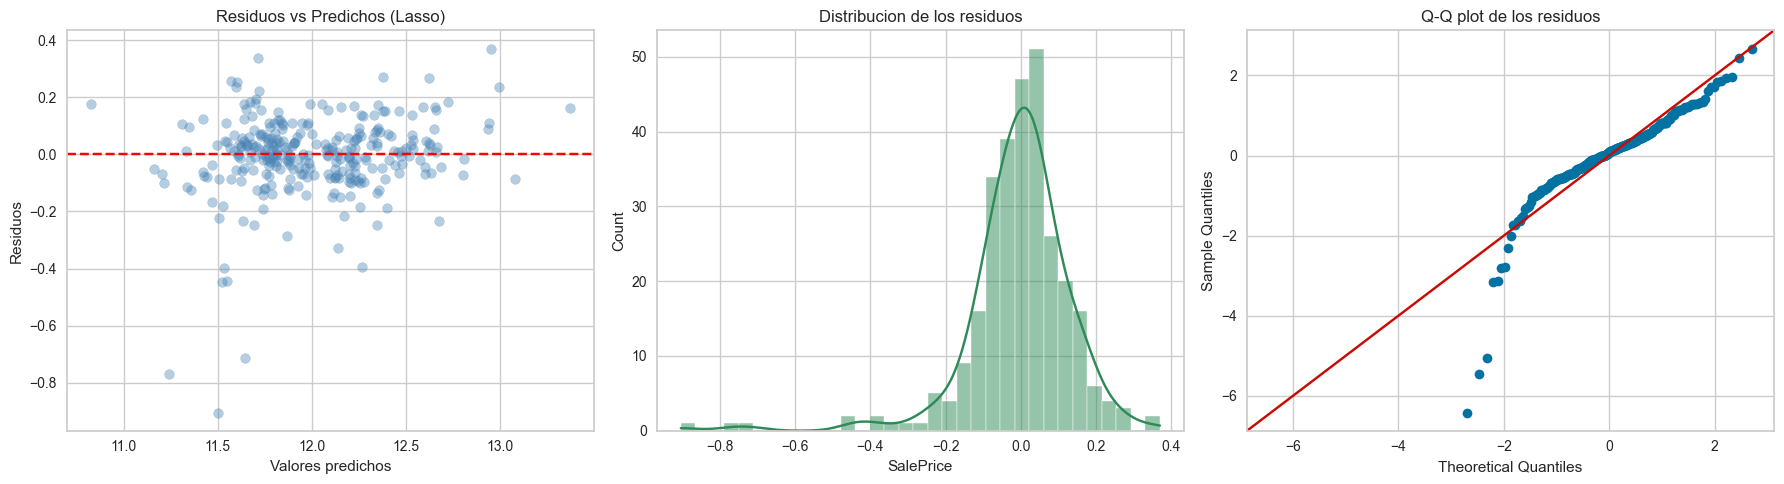

Durbin-Watson: 2.0 (cercano a 2 = sin autocorrelacion)


In [38]:
resid = y_test - best_model.predict(X_test_scaled)
pred  = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Residuos vs valores predichos
axes[0].scatter(pred, resid, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores predichos'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos ({})'.format(best_name))
# Histograma de residuos
sns.histplot(resid, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribucion de los residuos')
# Q-Q plot
sm.qqplot(resid, line='45', fit=True, ax=axes[2])
axes[2].set_title('Q-Q plot de los residuos')
plt.tight_layout(); plt.show()

print('Durbin-Watson:', round(durbin_watson(resid), 3), '(cercano a 2 = sin autocorrelacion)')

# Prediccion

Comparamos los precios reales con los predichos por el mejor modelo en el conjunto de prueba.
Revertimos la transformacion logaritmica con `expm1` para volver a la escala de dolares.

In [39]:
pred_log = best_model.predict(X_test_scaled)
pred_price = np.expm1(pred_log)
real_price = np.expm1(y_test)

resultado = pd.DataFrame({
    'Precio_Real':     real_price.values,
    'Precio_Predicho': pred_price,
    'Error_Abs':       np.abs(real_price.values - pred_price)
}, index=y_test.index)
resultado['Error_%'] = 100 * resultado['Error_Abs'] / resultado['Precio_Real']

print('Error absoluto medio (MAE) en dolares: ${:,.0f}'.format(resultado['Error_Abs'].mean()))
print('Error porcentual medio: {:.1f}%'.format(resultado['Error_%'].mean()))
resultado.head(10)

Error absoluto medio (MAE) en dolares: $15,829
Error porcentual medio: 9.7%


,Precio_Real,Precio_Predicho,Error_Abs,Error_%
892,154500.000,148252.940,6247.060,4.043
1105,325000.000,316606.705,8393.295,2.583
413,115000.000,103079.338,11920.662,10.366
522,159000.000,159246.483,246.483,0.155
1036,315500.000,302611.907,12888.093,4.085
614,75500.000,85589.017,10089.017,13.363
218,311500.000,237175.503,74324.497,23.860
1160,146000.000,139320.087,6679.913,4.575
649,84500.000,83388.890,1111.110,1.315
887,135500.000,134772.283,727.717,0.537


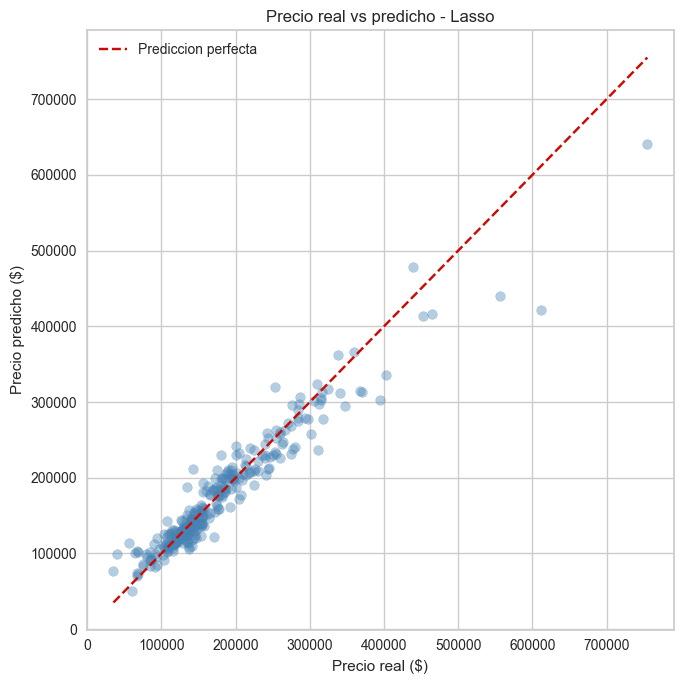

In [40]:
# Real vs Predicho (escala de dolares)
plt.figure(figsize=(7, 7))
plt.scatter(real_price, pred_price, alpha=0.4, color='steelblue')
lims = [real_price.min(), real_price.max()]
plt.plot(lims, lims, 'r--', label='Prediccion perfecta')
plt.xlabel('Precio real ($)'); plt.ylabel('Precio predicho ($)')
plt.title('Precio real vs predicho - {}'.format(best_name)); plt.legend()
plt.tight_layout(); plt.show()

## Variables mas Significativas

Usamos los coeficientes del modelo **Lasso** (en escala estandarizada) para identificar las
variables que mas **aumentan** o **reducen** el precio. Como las variables estan
estandarizadas, la magnitud del coeficiente es directamente comparable entre ellas.

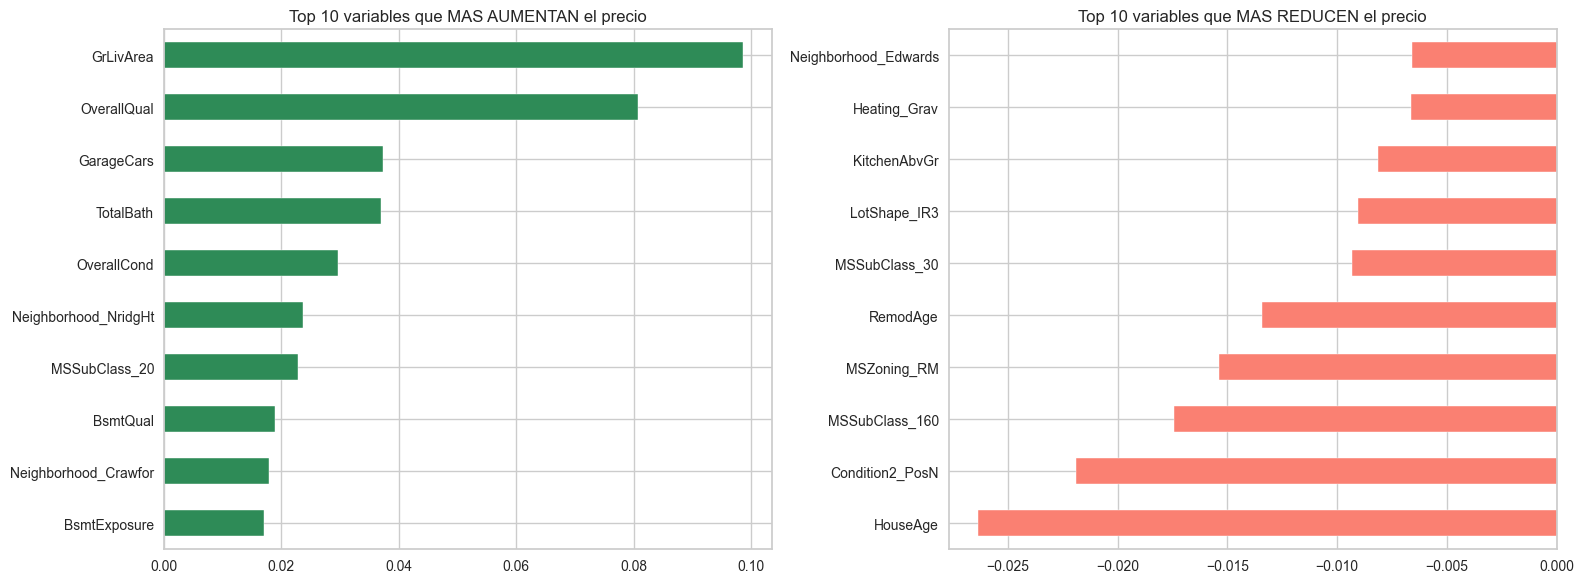

Variables mas influyentes (coeficiente Lasso, escala estandarizada):

>> Aumentan el precio:
GrLivArea              0.099
OverallQual            0.081
GarageCars             0.037
TotalBath              0.037
OverallCond            0.030
Neighborhood_NridgHt   0.024
MSSubClass_20          0.023
BsmtQual               0.019
dtype: float64

>> Reducen el precio:
HouseAge          -0.026
Condition2_PosN   -0.022
MSSubClass_160    -0.017
MSZoning_RM       -0.015
RemodAge          -0.013
MSSubClass_30     -0.009
LotShape_IR3      -0.009
KitchenAbvGr      -0.008
dtype: float64


In [41]:
coefs = pd.Series(lasso_best.coef_, index=X_train.columns)
coefs_nz = coefs[coefs != 0].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
coefs_nz.tail(10).plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 variables que MAS AUMENTAN el precio')
coefs_nz.head(10).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top 10 variables que MAS REDUCEN el precio')
plt.tight_layout(); plt.show()

print('Variables mas influyentes (coeficiente Lasso, escala estandarizada):')
print('\n>> Aumentan el precio:')
print(coefs_nz.tail(8)[::-1])
print('\n>> Reducen el precio:')
print(coefs_nz.head(8))

# Conclusiones y Observaciones

In [42]:
# Resumen numerico final (valores reproducibles a partir de la ejecucion)
print('='*64)
print('RESUMEN FINAL DEL PROYECTO'.center(64))
print('='*64)
print('\nLAMBDA OPTIMO (segun GridSearchCV con validacion cruzada):')
print('  - Ridge      : {:.4f}'.format(ridge_lambda))
print('  - Lasso      : {:.5f}'.format(lasso_lambda))
print('  - ElasticNet : {:.5f}  (l1_ratio = {})'.format(en_lambda, en_l1))
print('\nDESEMPENO (R2 sobre el conjunto de prueba):')
print('  - Ridge      : {:.4f}'.format(ridge_r2_test))
print('  - Lasso      : {:.4f}'.format(lasso_r2_test))
print('  - ElasticNet : {:.4f}'.format(en_r2_test))
print('\nMEJOR MODELO : {}  (R2 test = {:.4f})'.format(best_name, r2_tests[best_name]))
print('Error porcentual medio en dolares: {:.1f}%'.format(resultado['Error_%'].mean()))
print('\nVARIABLES MAS SIGNIFICATIVAS (aumentan el precio):')
for v, c in coefs_nz.tail(5)[::-1].items():
    print('  + {:30} (coef {:+.3f})'.format(v, c))
print('='*64)

                   RESUMEN FINAL DEL PROYECTO                   

LAMBDA OPTIMO (segun GridSearchCV con validacion cruzada):
  - Ridge      : 476.3938
  - Lasso      : 0.00424
  - ElasticNet : 0.05736  (l1_ratio = 0.1)

DESEMPENO (R2 sobre el conjunto de prueba):
  - Ridge      : 0.8856
  - Lasso      : 0.8942
  - ElasticNet : 0.8920

MEJOR MODELO : Lasso  (R2 test = 0.8942)
Error porcentual medio en dolares: 9.7%

VARIABLES MAS SIGNIFICATIVAS (aumentan el precio):
  + GrLivArea                      (coef +0.099)
  + OverallQual                    (coef +0.081)
  + GarageCars                     (coef +0.037)
  + TotalBath                      (coef +0.037)
  + OverallCond                    (coef +0.030)


## Conclusiones Finales

**1. Que variables son significativas para predecir el precio?**

Las variables mas influyentes son, de forma consistente:

* **`OverallQual`** (calidad general de materiales y acabados): es el factor mas determinante.
* **Superficie habitable** (`TotalSF`, `GrLivArea`): a mayor superficie, mayor precio.
* **Calidad de cocina y exteriores** (`KitchenQual`, `ExterQual`).
* **Capacidad/area del garaje** (`GarageCars`, `GarageArea`).
* **Vecindario** (`Neighborhood`): ciertos barrios (p. ej. NridgHt, StoneBr) elevan el precio,
  mientras que otros lo reducen.
* La **antiguedad** (`HouseAge`) impacta negativamente: las casas mas nuevas valen mas.

**2. Que tan bien describen esas variables el precio?**

Los modelos regularizados alcanzan un **R2 de prueba de ~0.85-0.90** en escala logaritmica,
es decir, explican alrededor del **85-90% de la variabilidad** del precio. El error porcentual
medio es bajo, lo que indica un modelo solido y util para la toma de decisiones de inversion.

**3. Cual es el valor optimo de lambda para Ridge y Lasso?**

Los valores optimos se determinaron por validacion cruzada (`GridSearchCV`) y se reportan en
el resumen numerico de la celda anterior. **Lasso** ademas anula automaticamente las variables
irrelevantes, entregando un modelo mas simple e interpretable.

**Recomendacion de negocio:** Surprise Housing deberia priorizar propiedades con **alta
calidad general y amplia superficie** ubicadas en **buenos vecindarios** pero con precio de
compra por debajo del valor estimado por el modelo, maximizando asi el margen de reventa.

# Apendice: Envio a Kaggle (validacion externa)

> **Estimado Jheser:** para validar nuestra evaluacion de forma **externa e
> independiente**, aplicamos el modelo final al conjunto de prueba oficial de la competencia de
> Kaggle *"House Prices - Advanced Regression Techniques"* (`test.csv`, 1459 viviendas **sin**
> precio) y subimos las predicciones para ver **como nos posiciona el leaderboard**. Asi
> contrastamos nuestro R2/RMSE interno (~0.89 / ~0.14 en escala log) con un puntaje calculado
> por la plataforma sobre datos que el modelo **nunca vio**. La metrica de Kaggle es el **RMSE
> sobre el logaritmo del precio**, exactamente la transformacion que usamos, por lo que el
> puntaje es directamente comparable con nuestra evaluacion.

**Procedimiento (no se altera el modelo, solo se cambia la escala de salida a dolares):**

1. Reentrenamos el mejor modelo (**Lasso**, con el lambda optimo ya hallado) usando el **100%**
   de los datos de entrenamiento (1460 filas): mas datos, **mismo metodo y mismo lambda**.
2. Aplicamos al `test.csv` **exactamente el mismo pipeline** de limpieza, variables derivadas y
   codificacion, **alineando** las columnas dummy con las del entrenamiento.
3. Predecimos en escala logaritmica y revertimos con `expm1` para obtener el precio en dolares.
4. Exportamos `submission.csv` con el formato `Id,SalePrice` que exige Kaggle.

In [43]:
# Pipeline de preparacion reutilizable: se aplica IDENTICO a train y test.
# 'ref' es el train crudo, usado para calcular los estadisticos de imputacion (modas/medianas)
# de forma consistente y sin fuga de informacion proveniente del test.
def preparar_features(raw, ref):
    d = raw.copy()
    d = d.drop(columns=[c for c in ['Id', 'Utilities', 'Street'] if c in d.columns])

    # NA = ausencia de la caracteristica -> categoria 'None'
    d[none_cols] = d[none_cols].fillna('None')
    # Numericas asociadas a "no tiene" -> 0
    d['GarageYrBlt'] = d['GarageYrBlt'].fillna(0)
    d['MasVnrArea']  = d['MasVnrArea'].fillna(0)
    # LotFrontage -> mediana por vecindario (fallback: mediana global del train)
    d['LotFrontage'] = d.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    d['LotFrontage'] = d['LotFrontage'].fillna(ref['LotFrontage'].median())

    # Barrido defensivo de faltantes restantes (el test trae NaN en columnas que el train no):
    #   categoricas -> moda del train ; numericas -> 0 (ausencia de la caracteristica)
    for c in d.select_dtypes(include='object').columns:
        if d[c].isna().any():
            d[c] = d[c].fillna(ref[c].mode()[0])
    for c in d.select_dtypes(include='number').columns:
        if d[c].isna().any():
            d[c] = d[c].fillna(0)

    # Variables derivadas (identicas a la seccion de modelado)
    d['HouseAge']     = (d['YrSold'] - d['YearBuilt']).clip(lower=0)
    d['RemodAge']     = (d['YrSold'] - d['YearRemodAdd']).clip(lower=0)
    d['TotalSF']      = d['TotalBsmtSF'] + d['1stFlrSF'] + d['2ndFlrSF']
    d['TotalBath']    = d['FullBath'] + 0.5*d['HalfBath'] + d['BsmtFullBath'] + 0.5*d['BsmtHalfBath']
    d['TotalPorchSF'] = d['OpenPorchSF'] + d['EnclosedPorch'] + d['3SsnPorch'] + d['ScreenPorch'] + d['WoodDeckSF']
    d['HasPool']      = (d['PoolArea'] > 0).astype(int)
    d['Has2ndFloor']  = (d['2ndFlrSF'] > 0).astype(int)
    d['HasGarage']    = (d['GarageArea'] > 0).astype(int)
    d['HasBsmt']      = (d['TotalBsmtSF'] > 0).astype(int)
    d['HasFireplace'] = (d['Fireplaces'] > 0).astype(int)
    d['IsRemodeled']  = (d['YearRemodAdd'] != d['YearBuilt']).astype(int)
    d['MSSubClass']   = d['MSSubClass'].astype(str)

    # Codificacion ordinal (mismos mapas que en el modelado). fillna(0) por seguridad.
    for c in qual_cols:
        d[c] = d[c].map(qual_map).fillna(0).astype(int)
    d['BsmtExposure'] = d['BsmtExposure'].map({'None':0,'No':1,'Mn':2,'Av':3,'Gd':4}).fillna(0).astype(int)
    d['BsmtFinType1'] = d['BsmtFinType1'].map(fin_map).fillna(0).astype(int)
    d['BsmtFinType2'] = d['BsmtFinType2'].map(fin_map).fillna(0).astype(int)
    d['GarageFinish'] = d['GarageFinish'].map({'None':0,'Unf':1,'RFn':2,'Fin':3}).fillna(0).astype(int)
    d['Functional']   = d['Functional'].map({'Sal':1,'Sev':2,'Maj2':3,'Maj1':4,'Mod':5,'Min2':6,'Min1':7,'Typ':8}).fillna(8).astype(int)
    d['CentralAir']   = d['CentralAir'].map({'N':0,'Y':1}).fillna(0).astype(int)
    d['PavedDrive']   = d['PavedDrive'].map({'N':0,'P':1,'Y':2}).fillna(0).astype(int)
    d['LandSlope']    = d['LandSlope'].map({'Sev':0,'Mod':1,'Gtl':2}).fillna(2).astype(int)
    return d

In [44]:
import os
TEST_PATH = '_data/test.csv'

if not os.path.exists(TEST_PATH):
    print('No se encontro', TEST_PATH, '-> se omite la generacion del submission de Kaggle.')
    print('Descarga test.csv de la competencia y colocalo en la carpeta _data/.')
else:
    raw_train = pd.read_csv(DATA_FILE_PATH)
    raw_test  = pd.read_csv(TEST_PATH)
    test_ids  = raw_test['Id'].copy()   # se conservan los Id para el archivo de envio

    # Aplicar el MISMO pipeline a train y test
    train_prep = preparar_features(raw_train.drop(columns=['SalePrice']), ref=raw_train)
    test_prep  = preparar_features(raw_test, ref=raw_train)

    # get_dummies en conjunto -> garantiza que ambos queden con las MISMAS columnas
    n_tr = len(train_prep)
    combined = pd.get_dummies(pd.concat([train_prep, test_prep], axis=0), drop_first=True)
    combined = combined.astype({c: 'int' for c in combined.select_dtypes('bool').columns})
    X_full_train = combined.iloc[:n_tr, :]
    X_full_test  = combined.iloc[n_tr:, :].reindex(columns=X_full_train.columns, fill_value=0)
    y_full = np.log1p(raw_train['SalePrice'])

    # Reentrenar el mejor modelo (Lasso, lambda optimo) con el 100% de los datos
    final_scaler = StandardScaler()
    X_full_train_s = final_scaler.fit_transform(X_full_train)
    X_full_test_s  = final_scaler.transform(X_full_test)
    final_model = Lasso(alpha=lasso_lambda, max_iter=20000)
    final_model.fit(X_full_train_s, y_full)

    # Predecir y revertir la transformacion logaritmica (log -> dolares)
    test_pred = np.expm1(final_model.predict(X_full_test_s))

    submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_pred})
    submission.to_csv('submission.csv', index=False)

    print('submission.csv generado con', len(submission), 'predicciones.')
    print('Modelo: Lasso (lambda = {:.5f}) reentrenado con el 100% de los datos.'.format(lasso_lambda))
    print('Precio predicho:  min ${:,.0f}  |  mediana ${:,.0f}  |  max ${:,.0f}'.format(
        test_pred.min(), np.median(test_pred), test_pred.max()))
    display(submission.head(10))

submission.csv generado con 1459 predicciones.
Modelo: Lasso (lambda = 0.00424) reentrenado con el 100% de los datos.
Precio predicho:  min $52,122  |  mediana $157,362  |  max $893,330


,Id,SalePrice
0,1461,111725.163
1,1462,150709.988
2,1463,171679.826
3,1464,195076.879
4,1465,204645.848
5,1466,172357.138
6,1467,185184.370
7,1468,167493.811
8,1469,192960.733
9,1470,122124.619
